# Swiss-roll ridge likelihood SMC — cleaned notebook dynamics with KL and W2 diagnostics

This cleaned notebook keeps the multiscale SDE dynamics in the same ODE/RHS style as the uploaded Swiss-roll notebook: the fixed Gaussian coefficients are evaluated through the vector-field RHS, and the code does **not** replace them with exact per-step noise integrals.

The structure is organized as:

1. Imports and configuration.
2. Swiss-roll prior and ridge likelihood.
3. Score-model training.
4. Multiscale fixed-noise SDE simulator using notebook-style dynamics.
5. Prior-generation sanity check.
6. Prior-gap likelihood hierarchy.
7. Reference posterior and level-wise target distributions \(Q_n\).
8. Branch/kill SMC.
9. KL, sliced \(W_2\), residual \(W_2\), and moment diagnostics.
10. Scatter plots comparing SMC, \(Q_n\), and the final target posterior.

The likelihood-tilted/FKP derivation uses the fixed-noise formulation with a fixed Gaussian coefficient rather than Brownian increments; this notebook keeps the uploaded notebook's practical ODE-solver implementation instead of exact integral updates.


In [1]:
%pip install --force-reinstall --no-cache-dir \
  "numpy==1.26.4" \
  "matplotlib==3.8.4" \
  "h5py==3.11.0"

!pip install -U "jax[cuda12]"

#1
!pip install --upgrade optax chex

#2
!pip install --upgrade git+https://github.com/google/flax.git

#3
!pip install -U --pre jax jaxlib "jax-cuda12-plugin[with-cuda]" jax-cuda12-pjrt -i https://us-python.pkg.dev/ml-oss-artifacts-published/jax/simple/

import subprocess

# Uninstall all current JAX components
subprocess.run(["pip", "uninstall", "-y", "jax", "jaxlib", "jax-cuda12-plugin", "jax-cuda12-pjrt"])

# Reinstall JAX 0.6.0 stack from official CUDA 12 wheel repo
subprocess.run([
    "pip", "install",
    "jax==0.6.0",
    "jaxlib==0.6.0",
    "jax-cuda12-plugin==0.6.0",
    "jax-cuda12-pjrt==0.6.0",
    "-f", "https://storage.googleapis.com/jax-releases/jax_cuda_releases.html"
])

!pip install \
  nvidia-cublas-cu12==12.8.4.1 \
  nvidia-cuda-cupti-cu12==12.9.19 \
  nvidia-cuda-nvcc-cu12==12.9.41 \
  nvidia-cuda-runtime-cu12==12.9.37 \
  nvidia-cudnn-cu12==9.10.1.4 \
  nvidia-cufft-cu12==11.4.0.6 \
  nvidia-cusolver-cu12==11.7.4.40 \
  nvidia-cusparse-cu12==12.5.9.5 \
  nvidia-nccl-cu12==2.26.5 \
  nvidia-nvjitlink-cu12==12.9.41 \
  nvidia-nvshmem-cu12==3.2.5

!pip uninstall -y nvidia-cublas-cu12
!pip install nvidia-cublas-cu12==12.8.4.1

!pip uninstall -y jax jaxlib flax optax chex \
  jax-cuda12-plugin jax-cuda12-pjrt \
  jax-cuda13-plugin jax-cuda13-pjrt

!pip install -U pip

!pip install \
  "jax[cuda12]==0.6.0" \
  "flax==0.10.4" \
  "optax==0.2.4" \
  "chex==0.1.89"

import os
os.environ.pop("LD_LIBRARY_PATH", None)
os.environ["JAX_PLATFORMS"] = "cuda,cpu"

import jax
import flax
import optax
import chex

print("JAX version:", jax.__version__)
print("Flax version:", flax.__version__)
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())

#@title
import jax
import numpy as np
import jax.numpy as jnp

from jax import grad, jit, vmap, random

import flax
import optax

from flax import linen as nn
from flax.training import train_state

from tqdm import trange
from functools import partial

print("JAX version:", jax.__version__)
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())

import jax
print("JAX version:", jax.__version__)
print("Backend:", jax.default_backend())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 287.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 142.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 142.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 51.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 647.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 460.0 MB/s  0:00:00
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0━━━━━━━  0/12 [six]
  Attempting uninstall: pyparsing━━━━━━━━━━━  0/12 [six]
    Found existing installation: pyparsing 3.3.2━━━━━━━━━━━━━━━━━━  1/12 [pyparsing]
    Uninstalling pyparsing-3.3.2:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/12 [pyparsing]
      Successfully uninstalled pyparsing-3.3.2━━━━━━━━━━━━━━━━  1/12 [pyparsing]
  Attempting uninstall: pillow━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/12 [pyparsing]


Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
  Using cached jax-0.6.0-py3-none-any.whl.metadata (22 kB)
  Using cached jaxlib-0.6.0-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached jax_cuda12_plugin-0.6.0-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.4 kB)
  Using cached jax_cuda12_pjrt-0.6.0-py3-none-manylinux2014_x86_64.whl.metadata (492 bytes)
Using cached jax-0.6.0-py3-none-any.whl (2.3 MB)
Using cached jaxlib-0.6.0-cp311-cp311-manylinux2014_x86_64.whl (87.8 MB)
Using cached jax_cuda12_plugin-0.6.0-cp311-cp311-manylinux2014_x86_64.whl (15.8 MB)
Using cached jax_cuda12_pjrt-0.6.0-py3-none-manylinux2014_x86_64.whl (123.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jax]3/4 [jax]ib]a12-plugin]


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.12.7 requires jax>=0.10.0, but you have jax 0.6.0 which is incompatible.
chex 0.1.91 requires jax>=0.7.0, but you have jax 0.6.0 which is incompatible.
chex 0.1.91 requires jaxlib>=0.7.0, but you have jaxlib 0.6.0 which is incompatible.
lineax 0.1.1 requires jax>=0.10.0, but you have jax 0.6.0 which is incompatible.


Found existing installation: nvidia-cublas-cu12 12.8.4.1
Uninstalling nvidia-cublas-cu12-12.8.4.1:
  Successfully uninstalled nvidia-cublas-cu12-12.8.4.1
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl (594.3 MB)
Found existing installation: jax 0.6.0
Uninstalling jax-0.6.0:
  Successfully uninstalled jax-0.6.0
Found existing installation: jaxlib 0.6.0
Uninstalling jaxlib-0.6.0:
  Successfully uninstalled jaxlib-0.6.0
Found existing installation: flax 0.12.7
Uninstalling flax-0.12.7:
  Successfully uninstalled flax-0.12.7
Found existing installation: optax 0.2.8
Uninstalling optax-0.2.8:
  Successfully uninstalled optax-0.2.8
Found existing installation: chex 0.1.91
Uninstalling chex-0.1.91:
  Successfully uninstalled chex-0.1.91
Found existing installation: jax-cuda12-plugin 0.6.0
Uninstalling jax-cuda12-plugin-0.6.0:
  Successfully uninstalled jax-cuda12-plugin-

In [3]:




# ============================================================
# Imports and configuration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.scipy.special as jsp_special
from jax import random
from functools import partial

import flax.linen as nn
from flax.training import train_state
import optax
from tqdm.auto import trange

print("JAX version:", jax.__version__)
print("Backend:", jax.default_backend())















SEED = 0
key = random.PRNGKey(SEED)
np.random.seed(SEED)

DIM = 2

# Swiss-roll prior
SWISS_THETA_MIN = 1.0 * np.pi
SWISS_THETA_MAX = 7.0 * np.pi
SWISS_SCALE = 0.20

# Score training
TRAIN_BS = 5000
NUM_ITERATIONS = 20000       # increase to 20_000 if desired
MLP_HIDDEN = 512
LEARNING_RATE = 2e-4

# Notebook-style fixed-noise multiscale SDE
T0 = 0.01
T1 = 1.0
N_STEPS = 256
# Keep the uploaded notebook dynamics: base noise enters as +omega0 in the ODE RHS.
# Set to "sqrt_2_over_t" only if you intentionally want the theoretical base coefficient.
BASE_NOISE_MODE = "notebook_constant"  # "notebook_constant" or "sqrt_2_over_t"
NUM_SMC_LEVELS = 5
NUM_REF_LEVELS = NUM_SMC_LEVELS + 5
B_TAIL = 5000
BS_SMC = 5000

# Ridge likelihood: A x ≈ y
A_OBS = jnp.asarray([[1.0, 1.0]], dtype=jnp.float32)
y_obs = jnp.asarray([0.0], dtype=jnp.float32)
DELTA_OBS = 0.25
OBS_NOISE_VAR = float(DELTA_OBS**2)
NORMALIZE_LIKELIHOOD_BY_DIM = False

# Reference / target construction
B_REF_POSTERIOR = 5_000
N_REF_POSTERIOR = 5_000
B_TARGET_REF = 5000
N_TARGET_PLOT = 5000

# KL histogram
KL_BINS = 1200
KL_PSEUDOCOUNT = 1e-8

print("Configuration loaded.")


JAX version: 0.6.0
Backend: gpu
Configuration loaded.


## 1. Swiss-roll prior and ridge likelihood


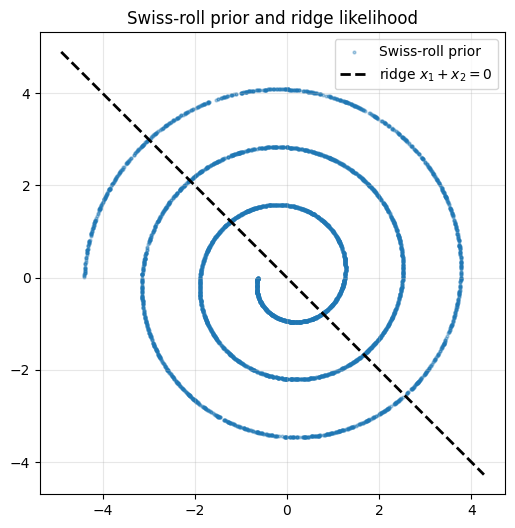

In [4]:
# ============================================================
# Swiss-roll prior sampler and ridge likelihood
# ============================================================

def sample_swiss_roll_np(n, seed=0):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(SWISS_THETA_MIN, SWISS_THETA_MAX, size=(n,))
    x = SWISS_SCALE * theta * np.cos(theta)
    z = SWISS_SCALE * theta * np.sin(theta)
    return np.stack([x, z], axis=1).astype(np.float32)


def sample_data(key, bs):
    theta = random.uniform(
        key,
        shape=(bs,),
        minval=float(SWISS_THETA_MIN),
        maxval=float(SWISS_THETA_MAX),
    )
    x = SWISS_SCALE * theta * jnp.cos(theta)
    z = SWISS_SCALE * theta * jnp.sin(theta)
    return jnp.stack([x, z], axis=1).astype(jnp.float32)


def apply_observation(x):
    return x @ A_OBS.T


def log_final_ridge_likelihood(x, eps=1e-8):
    Ax = apply_observation(x)
    res = y_obs[None, :] - Ax
    quad = jnp.sum(res**2, axis=1) / (OBS_NOISE_VAR + eps)
    return -0.5 * quad


prior_demo = sample_swiss_roll_np(5000, seed=123)
plt.figure(figsize=(6, 6))
plt.scatter(prior_demo[:, 0], prior_demo[:, 1], s=4, alpha=0.35, label="Swiss-roll prior")
xx = np.linspace(prior_demo[:, 0].min()-0.5, prior_demo[:, 0].max()+0.5, 200)
plt.plot(xx, -xx, "k--", linewidth=2, label=r"ridge $x_1+x_2=0$")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Swiss-roll prior and ridge likelihood")
plt.show()


## 2. Score model training


In [5]:
# ============================================================
# Noising schedule and ScoreMLP
# ============================================================

beta_0 = 0.1
beta_1 = 20.0

log_alpha = lambda t: -0.5 * t * beta_0 - 0.25 * t**2 * (beta_1 - beta_0)
log_sigma = lambda t: 0.5 * jnp.log(jnp.maximum(2.0 * t - t**2, 1e-8))


class ScoreMLP(nn.Module):
    hidden: int = 512
    out_dim: int = 2

    @nn.compact
    def __call__(self, t, x):
        if t.ndim == 0:
            t = jnp.ones((x.shape[0], 1), dtype=x.dtype) * t
        elif t.ndim == 1:
            t = t[:, None]
        h = jnp.concatenate([t, x], axis=1)
        h = nn.Dense(self.hidden)(h)
        h = nn.swish(h)
        h = nn.Dense(self.hidden)(h)
        h = nn.swish(h)
        h = nn.Dense(self.hidden)(h)
        h = nn.swish(h)
        h = nn.Dense(self.out_dim)(h)
        return h


model = ScoreMLP(hidden=MLP_HIDDEN, out_dim=DIM)
key, init_key = random.split(key)
variables = model.init(init_key, jnp.ones((4,1)), jnp.zeros((4,DIM)))

optimizer = optax.adam(LEARNING_RATE)
state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=variables["params"],
    tx=optimizer,
)
print(model)


ScoreMLP(
    # attributes
    hidden = 512
    out_dim = 2
)


In [6]:
# ============================================================
# Denoising score matching
# ============================================================

def sm_loss(params, apply_fn, key, bs):
    k0, k1, k2 = random.split(key, 3)
    x0 = sample_data(k0, bs)
    t = random.uniform(k1, shape=(bs, 1), minval=1e-4, maxval=1.0-1e-4)
    eps = random.normal(k2, shape=x0.shape)

    rev_t = 1.0 - t
    alpha = jnp.exp(log_alpha(rev_t))
    sigma = jnp.exp(log_sigma(rev_t))
    x_noisy = alpha * x0 + sigma * eps

    pred = apply_fn({"params": params}, rev_t, x_noisy)
    return jnp.mean(jnp.sum((eps + sigma * pred)**2, axis=1))


@partial(jax.jit, static_argnums=(1,3))
def train_step(state, apply_fn, key, bs):
    loss, grads = jax.value_and_grad(lambda p: sm_loss(p, apply_fn, key, bs))(state.params)
    return state.apply_gradients(grads=grads), loss


key, smoke_key = random.split(key)
state, smoke_loss = train_step(state, state.apply_fn, smoke_key, TRAIN_BS)
print("smoke loss:", float(smoke_loss))


smoke loss: 1.7891712188720703


  0%|          | 0/20000 [00:00<?, ?it/s]

iter 1000: loss=0.791421
iter 2000: loss=0.813347
iter 3000: loss=0.784886
iter 4000: loss=0.798611
iter 5000: loss=0.746894
iter 6000: loss=0.803716
iter 7000: loss=0.771157
iter 8000: loss=0.755711
iter 9000: loss=0.776223
iter 10000: loss=0.775451
iter 11000: loss=0.745612
iter 12000: loss=0.751396
iter 13000: loss=0.746017
iter 14000: loss=0.751984
iter 15000: loss=0.728709
iter 16000: loss=0.748586
iter 17000: loss=0.728434
iter 18000: loss=0.728907
iter 19000: loss=0.750374
iter 20000: loss=0.707145


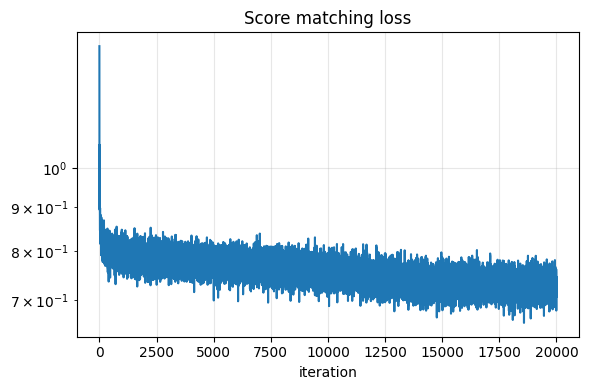

In [7]:
# ============================================================
# Train score model
# ============================================================

loss_plot = np.zeros(NUM_ITERATIONS, dtype=np.float32)
key, loop_key = random.split(key)

for it in trange(NUM_ITERATIONS):
    state, loss = train_step(state, state.apply_fn, random.fold_in(loop_key, it), TRAIN_BS)
    loss_plot[it] = float(loss)
    if (it + 1) % 1000 == 0:
        print(f"iter {it+1}: loss={loss_plot[it]:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(loss_plot)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.title("Score matching loss")
plt.xlabel("iteration")
plt.tight_layout()
plt.show()


## 3. Notebook-style fixed-noise multiscale SDE simulator

This block keeps the dynamics in the same ODE-solver form as the uploaded notebook. In particular, it does **not** pre-integrate the noise coefficient over each time step. The base-level fixed noise defaults to the notebook convention `+ omega0`; the higher-level Haar-like white levels keep the notebook's `sqrt(2/t)` factor inside the RHS.


In [8]:

# ============================================================
# Notebook-style fixed-noise multiscale SDE simulator
# No exact per-time-step integration of the noise coefficients.
# ============================================================


def score_apply(params, apply_fn, tau, x):
    """
    Apply trained score model s_theta(tau, x).
    """
    if jnp.ndim(tau) == 0:
        tau_batched = tau * jnp.ones((x.shape[0], 1), dtype=x.dtype)
    elif tau.ndim == 1:
        tau_batched = tau[:, None]
    else:
        tau_batched = tau
    return apply_fn({"params": params}, tau_batched, x)



def base_drift(t, y, params, apply_fn):
    """
    v_t(y) = (y + 2 score_{1-t}(y)) / t.
    """
    t_safe = jnp.maximum(t, 1e-6)
    tau = 1.0 - t_safe
    score = score_apply(params, apply_fn, tau, y)
    return (y + 2.0 * score) / t_safe


# Keep this alias because later cells use vector_field in diagnostics.
def vector_field(params, apply_fn, t, x):
    return base_drift(t, x, params, apply_fn)


# ------------------------------------------------------------
# Haar-like fixed-noise basis from the uploaded notebook
# ------------------------------------------------------------

def psi(t, n, k):
    """
    JAX-safe Haar-like pair basis used in the uploaded notebook.

    Returns shape (2,). This is intentionally kept in the original
    piecewise-RHS style rather than exact time-integrating coefficients.
    """
    d = 2.0 ** (-(n - 1))

    I0 = (k - 1) * d
    I1 = k * d
    I2 = (k + 1) * d

    scale = 2.0 ** ((n - 2) / 2)

    cond1 = (t > I0) & (t < I1)
    cond2 = (t > I1) & (t < I2)

    val1 = jnp.array([1.0, 0.0], dtype=jnp.float32) * scale
    val2 = jnp.array([0.0, -1.0], dtype=jnp.float32) * scale
    val0 = jnp.array([0.0, 0.0], dtype=jnp.float32)

    return jnp.where(cond1, val1, jnp.where(cond2, val2, val0))



def generate_eta_batch(max_n, batch_size, key):
    """
    eta has shape (batch_size, 2**(n-1)).
    """
    num_k = 2 ** (max_n - 1)
    return random.normal(key, shape=(batch_size, num_k), dtype=jnp.float32)



def white_level(t, n, eta_n_batch):
    """
    Uploaded-notebook white-level coefficient.

    Args:
        t: scalar
        n: Haar/Lévy level
        eta_n_batch: (batch_size, 2**(n-1))

    Returns:
        (batch_size,)
    """
    t_safe = jnp.maximum(t, 1e-6)

    if n == 1:
        return eta_n_batch[:, 0] * jnp.sqrt(2.0 / t_safe)

    num_k_iter = 2 ** (n - 2)
    k_values = 2 * jnp.arange(num_k_iter) + 1

    psi_vec = jax.vmap(lambda k: psi(t_safe, n, k))(k_values)  # (num_k_iter, 2)
    psi_flat = psi_vec.reshape(-1)                            # (2**(n-1),)

    sqrt_factor = jnp.sqrt(2.0 / t_safe)
    scal = 2.0 ** (-(n) / 2)

    return jnp.sum(psi_flat[None, :] * eta_n_batch, axis=1) * sqrt_factor * scal



def generate_2d_white_level_noise(t, n_level, eta_x_batch, eta_y_batch):
    noise_x = white_level(t, n_level, eta_x_batch)
    noise_y = white_level(t, n_level, eta_y_batch)
    return jnp.stack([noise_x, noise_y], axis=-1)


# ------------------------------------------------------------
# Current path lookup and increment drift
# ------------------------------------------------------------

def select_path_at_time(t, paths_bt, t0=T0, t1=T1):
    """
    paths_bt: (batch_size, T, dim)
    Select stored S_t approximately using nearest/floor saved index.
    """
    T = paths_bt.shape[1]
    alpha = (t - t0) / (t1 - t0)
    idx = jnp.floor(alpha * (T - 1)).astype(jnp.int32)
    idx = jnp.clip(idx, 0, T - 1)
    return paths_bt[:, idx, :]



def increment_drift(t, y, current_paths_bt, params, apply_fn, t0=T0, t1=T1):
    """
    Telescoping increment drift in the uploaded notebook's form:

        dX^n/dt = [F(S^{n-1}+X^n)-F(S^{n-1})]

    where F uses the same score time convention as base_drift.
    """
    t_safe = jnp.maximum(t, 1e-6)
    x_base = select_path_at_time(t_safe, current_paths_bt, t0=t0, t1=t1)
    return base_drift(t_safe, x_base + y, params, apply_fn) - base_drift(t_safe, x_base, params, apply_fn)


# ------------------------------------------------------------
# Base and increment simulators
# ------------------------------------------------------------

def simulate_base_level(
    key,
    batch_size,
    params,
    apply_fn,
    n_steps=N_STEPS,
    t0=T0,
    t1=T1,
    dt0=0.01,
):
    """
    Simulate base prior level S^0 using the uploaded notebook's ODE RHS.

    Default:
        dY_t/dt = v_t(Y_t) + omega0

    If BASE_NOISE_MODE == "sqrt_2_over_t", then:
        dY_t/dt = v_t(Y_t) + sqrt(2/t) omega0

    No exact per-step noise integration is used in either case.
    """
    key_y0, key_noise = random.split(key)

    y0 = random.normal(key_y0, shape=(batch_size, DIM), dtype=jnp.float32)
    omega0 = random.normal(key_noise, shape=(batch_size, DIM), dtype=jnp.float32)

    def vf_base(t, y, args):
        params, omega0 = args
        drift = base_drift(t, y, params, apply_fn)
        if BASE_NOISE_MODE == "sqrt_2_over_t":
            noise = jnp.sqrt(2.0 / jnp.maximum(t, 1e-6)) * omega0
        else:
            noise = omega0
        return drift + noise

    term = ODETerm(vf_base)
    saveat = SaveAt(ts=jnp.linspace(t0, t1, n_steps + 1))

    sol = diffeqsolve(
        terms=term,
        solver=Tsit5(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=(params, omega0),
        saveat=saveat,
    )

    return sol.ys



def simulate_increment_level(
    key,
    noise_level,
    current_paths,
    params,
    apply_fn,
    n_steps=N_STEPS,
    t0=T0,
    t1=T1,
    dt0=0.01,
):
    """
    Simulate one telescoping increment level with the uploaded notebook's
    ODE RHS and white_level(t,n)*sqrt(2/t) noise term.

    current_paths: (T, batch_size, 2), stores S^{n-1}_t.
    Returns increment paths with shape (T, batch_size, 2).
    """
    batch_size = current_paths.shape[1]
    current_paths_bt = current_paths.transpose(1, 0, 2)

    key_x, key_y = random.split(key)

    eta_x_batch = generate_eta_batch(
        max_n=noise_level,
        batch_size=batch_size,
        key=key_x,
    )
    eta_y_batch = generate_eta_batch(
        max_n=noise_level,
        batch_size=batch_size,
        key=key_y,
    )

    y0 = jnp.zeros((batch_size, DIM), dtype=current_paths.dtype)

    def vf_increment(t, y, args):
        current_paths_bt, params, eta_x, eta_y = args
        noise = generate_2d_white_level_noise(t, noise_level, eta_x, eta_y)
        drift = increment_drift(t, y, current_paths_bt, params, apply_fn, t0=t0, t1=t1)
        return drift + noise

    term = ODETerm(vf_increment)
    saveat = SaveAt(ts=jnp.linspace(t0, t1, n_steps + 1))

    sol = diffeqsolve(
        terms=term,
        solver=Dopri8(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=(current_paths_bt, params, eta_x_batch, eta_y_batch),
        saveat=saveat,
    )

    return sol.ys



def simulate_prior_hierarchy_with_increments(
    key,
    batch_size,
    num_levels,
    params,
    apply_fn,
    n_steps=N_STEPS,
    t0=T0,
    t1=T1,
):
    """
    Returns:
        paths_by_level[ell] = S^ell_t, shape (T, B, 2)
        increments_by_level[ell] = X^ell_t, shape (T, B, 2)

    paths_by_level[0] = S^0.
    paths_by_level[1] = S^0 + X^1.
    """
    keys = random.split(key, num_levels)

    paths_by_level = []
    increments_by_level = []

    current_paths = simulate_base_level(
        keys[0],
        batch_size=batch_size,
        params=params,
        apply_fn=apply_fn,
        n_steps=n_steps,
        t0=t0,
        t1=t1,
    )

    paths_by_level.append(current_paths)
    increments_by_level.append(current_paths)

    for ell in range(1, num_levels):
        inc_paths = simulate_increment_level(
            keys[ell],
            noise_level=ell + 1,
            current_paths=current_paths,
            params=params,
            apply_fn=apply_fn,
            n_steps=n_steps,
            t0=t0,
            t1=t1,
        )
        current_paths = current_paths + inc_paths
        increments_by_level.append(inc_paths)
        paths_by_level.append(current_paths)

    return paths_by_level, increments_by_level



def check_increment_identity(paths_by_level, increments_by_level):
    for ell in range(1, len(paths_by_level)):
        err = jnp.max(jnp.abs(paths_by_level[ell] - paths_by_level[ell - 1] - increments_by_level[ell]))
        print(f"level {ell+1}: max |S_new - S_prev - inc| = {float(err):.3e}")


print("Notebook-style multiscale SDE simulator defined.")
print("BASE_NOISE_MODE:", BASE_NOISE_MODE)


Notebook-style multiscale SDE simulator defined.
BASE_NOISE_MODE: notebook_constant


## 4. Prior-generation sanity check




/usr/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


  Using cached jax-0.10.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.1-cp311-cp311-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
Using cached jax-0.10.1-py3-none-any.whl (3.2 MB)
Using cached jaxlib-0.10.1-cp311-cp311-manylinux_2_27_x86_64.whl (85.8 MB)
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.6.0
    Uninstalling jaxlib-0.6.0:
      Successfully uninstalled jaxlib-0.6.0
  Attempting uninstall: jax━━━━━━━━━━━━━━━━━━━━━ 0/2 [jaxlib]
    Found existing installation: jax 0.6.0━━ 0/2 [jaxlib]
    Uninstalling jax-0.6.0:━━━━━━━━━━━━━━━━━ 0/2 [jaxlib]
      Successfully uninstalled jax-0.6.00m━━━━━━━━━━━━━━━━━━━ 1/2 [jax]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jax]1/2 [jax]


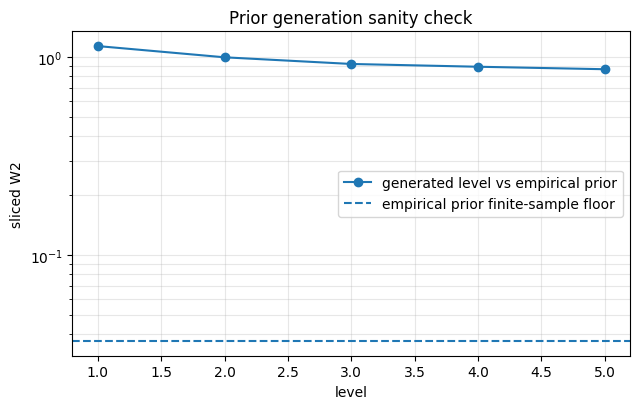

generated vs empirical prior sliced W2: [1.13492412 0.99616708 0.92193838 0.8926736  0.86726338]
empirical prior floor: 0.036872120517316954


In [9]:


import numpy as np
import matplotlib.pyplot as plt


!pip install diffrax
from diffrax import diffeqsolve, ODETerm, Tsit5, Dopri8, SaveAt
import jax.scipy.special as jsp_special
# ============================================================


# Prior-generation sanity check
# ============================================================

RUN_PRIOR_SANITY_CHECK = True

def flatten_samples(x):
    x = np.asarray(jax.device_get(x)) if not isinstance(x, np.ndarray) else x
    return x.reshape(x.shape[0], -1).astype(np.float64)


def sliced_w2_samples(X, Y, num_projections=256, max_points=5000, seed=0):
    X = flatten_samples(X)
    Y = flatten_samples(Y)
    rng = np.random.default_rng(seed)
    if len(X) > max_points:
        X = X[rng.choice(len(X), size=max_points, replace=False)]
    if len(Y) > max_points:
        Y = Y[rng.choice(len(Y), size=max_points, replace=False)]
    k = min(len(X), len(Y))
    X, Y = X[:k], Y[:k]
    dirs = rng.normal(size=(num_projections, X.shape[1]))
    dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
    return np.sqrt(np.mean((np.sort(X @ dirs.T, axis=0) - np.sort(Y @ dirs.T, axis=0))**2))


if RUN_PRIOR_SANITY_CHECK:
    key, prior_key = random.split(key)
    paths_prior_check, _ = simulate_prior_hierarchy_with_increments(
        prior_key, 5000, NUM_SMC_LEVELS, state.params, state.apply_fn, n_steps=N_STEPS
    )
    direct_prior_1 = sample_swiss_roll_np(5000, seed=900)
    direct_prior_2 = sample_swiss_roll_np(5000, seed=901)
    floor = sliced_w2_samples(direct_prior_1, direct_prior_2, seed=10)
    gen_vs_prior = np.array([
        sliced_w2_samples(paths_prior_check[ell][-1], direct_prior_1, seed=100 + ell)
        for ell in range(NUM_SMC_LEVELS)
    ])
    levels = np.arange(1, NUM_SMC_LEVELS + 1)
    plt.figure(figsize=(6.5, 4.2))
    plt.semilogy(levels, gen_vs_prior, marker="o", label="generated level vs empirical prior")
    plt.axhline(floor, linestyle="--", label="empirical prior finite-sample floor")
    plt.xlabel("level")
    plt.ylabel("sliced W2")
    plt.title("Prior generation sanity check")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("generated vs empirical prior sliced W2:", gen_vs_prior)
    print("empirical prior floor:", floor)


## 5. Prior-gap likelihood hierarchy


In [10]:
# ============================================================
# Observation-space likelihood hierarchy
# ============================================================

def to_np(x):
    try:
        return np.asarray(jax.device_get(x))
    except Exception:
        return np.asarray(x)


def empirical_diag_var_obs(Z):
    Zc = Z - jnp.mean(Z, axis=0, keepdims=True)
    return jnp.sum(Zc**2, axis=0) / jnp.maximum(Z.shape[0] - 1, 1)


def avg_obs_var(Z):
    return jnp.mean(empirical_diag_var_obs(Z))


def make_observation_prior_gap_likelihood_hierarchy(paths_by_level, apply_A, obs_noise_var, num_smc_levels, ref_index=-1, use_monotone=True, eps=1e-12):
    finals = jnp.stack([p[-1] for p in paths_by_level], axis=0)
    S_ref = finals[ref_index]
    Z_ref = apply_A(S_ref)
    tau_ref2 = avg_obs_var(Z_ref)
    tail_means_obs, tail_diag_vars_obs, level_vars, tail_vars, gap_vars = [], [], [], [], []
    for ell in range(num_smc_levels):
        Z_ell = apply_A(finals[ell])
        E_ell = Z_ref - Z_ell
        mu_E = jnp.mean(E_ell, axis=0)
        diag_var_E = empirical_diag_var_obs(E_ell)
        tau_level2 = avg_obs_var(Z_ell)
        tau_tail2 = jnp.mean(diag_var_E)
        gap = jnp.maximum(tau_ref2 - tau_level2, 0.0)
        tail_means_obs.append(mu_E)
        tail_diag_vars_obs.append(diag_var_E)
        level_vars.append(tau_level2)
        tail_vars.append(tau_tail2)
        gap_vars.append(gap)
    tail_means_obs = jnp.stack(tail_means_obs)
    tail_diag_vars_obs = jnp.stack(tail_diag_vars_obs)
    level_vars = jnp.asarray(level_vars)
    tail_vars = jnp.asarray(tail_vars)
    gap_vars = jnp.asarray(gap_vars)
    if use_monotone:
        gap_vars = jnp.asarray(np.minimum.accumulate(np.asarray(jax.device_get(gap_vars))))
    eta = jnp.sqrt(gap_vars / (tail_vars + eps))
    obs_biases, obs_vars = [], []
    for ell in range(num_smc_levels):
        b_ell = eta[ell] * tail_means_obs[ell]
        var_ell = obs_noise_var + (eta[ell] ** 2) * tail_diag_vars_obs[ell]
        obs_biases.append(b_ell)
        obs_vars.append(var_ell)
    return {
        "obs_biases": jnp.stack(obs_biases),
        "obs_vars": jnp.stack(obs_vars),
        "eta": eta,
        "gap_vars": gap_vars,
        "tail_vars": tail_vars,
        "level_vars": level_vars,
        "tau_ref2": tau_ref2,
        "tail_means_obs": tail_means_obs,
        "tail_diag_vars_obs": tail_diag_vars_obs,
    }


key, tail_key = random.split(key)
paths_prior_pilot, increments_prior_pilot = simulate_prior_hierarchy_with_increments(
    tail_key, B_TAIL, NUM_REF_LEVELS, state.params, state.apply_fn, n_steps=N_STEPS
)
check_increment_identity(paths_prior_pilot, increments_prior_pilot)

obs_like = make_observation_prior_gap_likelihood_hierarchy(
    paths_prior_pilot, apply_observation, OBS_NOISE_VAR, NUM_SMC_LEVELS, ref_index=-1, use_monotone=True
)
obs_biases = obs_like["obs_biases"]
obs_vars = obs_like["obs_vars"]
eta = obs_like["eta"]

print("Observation-space likelihood hierarchy:")
print("tau_ref^2:", float(obs_like["tau_ref2"]))
for ell in range(NUM_SMC_LEVELS):
    print(
        f"level {ell+1}: tau_level^2={float(obs_like['level_vars'][ell]):.6f}, "
        f"gap={float(obs_like['gap_vars'][ell]):.6f}, "
        f"tail_var={float(obs_like['tail_vars'][ell]):.6f}, "
        f"eta={float(eta[ell]):.4f}, mean obs_var={float(jnp.mean(obs_vars[ell])):.6f}"
    )


level 2: max |S_new - S_prev - inc| = 2.384e-07
level 3: max |S_new - S_prev - inc| = 2.384e-07
level 4: max |S_new - S_prev - inc| = 2.384e-07
level 5: max |S_new - S_prev - inc| = 2.384e-07
level 6: max |S_new - S_prev - inc| = 2.384e-07
level 7: max |S_new - S_prev - inc| = 2.347e-07
level 8: max |S_new - S_prev - inc| = 2.384e-07
level 9: max |S_new - S_prev - inc| = 2.384e-07
level 10: max |S_new - S_prev - inc| = 2.384e-07
Observation-space likelihood hierarchy:
tau_ref^2: 2.6528398990631104
level 1: tau_level^2=1.569035, gap=1.083805, tail_var=1.757692, eta=0.7852, mean obs_var=1.146305
level 2: tau_level^2=2.011203, gap=0.641637, tail_var=1.120065, eta=0.7569, mean obs_var=0.704137
level 3: tau_level^2=2.290615, gap=0.362225, tail_var=0.729384, eta=0.7047, mean obs_var=0.424725
level 4: tau_level^2=2.443982, gap=0.208858, tail_var=0.454718, eta=0.6777, mean obs_var=0.271358
level 5: tau_level^2=2.538133, gap=0.114707, tail_var=0.294776, eta=0.6238, mean obs_var=0.177207


## 6. Reference posterior and level-wise target distributions


In [11]:
# ============================================================
# Reference posterior and level-wise target distributions Q_n
# ============================================================

def normalize_logweights_np(logw):
    lw = np.asarray(logw, dtype=np.float64)
    lw = lw - np.max(lw)
    w = np.exp(lw)
    return w / np.sum(w)


def weighted_resample_np(X, logw, num_samples, seed=0):
    w = normalize_logweights_np(logw)
    ess = 1.0 / np.sum(w**2)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=num_samples, replace=True, p=w)
    return X[idx], w, ess, idx


def log_observation_gaussian_unnorm(x, y_obs, obs_bias, obs_var, apply_A, normalize_by_dim=False, eps=1e-8):
    Ax = apply_A(x)
    res = y_obs[None, :] - Ax - obs_bias[None, :]
    quad_per_coord = (res**2) / (obs_var[None, :] + eps)
    quad = jnp.mean(quad_per_coord, axis=1) if normalize_by_dim else jnp.sum(quad_per_coord, axis=1)
    return -0.5 * quad


prior_samples_ref = sample_swiss_roll_np(B_REF_POSTERIOR, seed=500)
logw_ref = to_np(log_final_ridge_likelihood(jnp.asarray(prior_samples_ref)))
posterior_samples, posterior_weights, posterior_ref_ess, _ = weighted_resample_np(
    prior_samples_ref, logw_ref, num_samples=N_REF_POSTERIOR, seed=501
)
print("Reference posterior samples:", posterior_samples.shape)
print("Reference posterior ESS/N:", posterior_ref_ess / B_REF_POSTERIOR)


def build_levelwise_target_reference(key, num_ref_samples=B_TARGET_REF, num_target_samples=N_TARGET_PLOT, seed=456):
    key, ref_key = random.split(key)
    paths_ref, _ = simulate_prior_hierarchy_with_increments(
        ref_key, num_ref_samples, NUM_SMC_LEVELS, state.params, state.apply_fn, n_steps=N_STEPS
    )
    target_samples_by_level, target_weights_by_level, target_ess_by_level, prior_level_samples = [], [], [], []
    for ell in range(NUM_SMC_LEVELS):
        X_ell = paths_ref[ell][-1]
        logw_ell = log_observation_gaussian_unnorm(
            X_ell, y_obs, obs_biases[ell], obs_vars[ell], apply_observation, NORMALIZE_LIKELIHOOD_BY_DIM
        )
        X_np = to_np(X_ell)
        X_target, w, ess, idx = weighted_resample_np(X_np, to_np(logw_ell), num_samples=num_target_samples, seed=seed+ell)
        target_samples_by_level.append(X_target)
        target_weights_by_level.append(w)
        target_ess_by_level.append(ess)
        prior_level_samples.append(X_np)
        print(f"target Q_{ell+1}: reference ESS={ess:.2f}, ESS/N={ess/len(X_np):.4f}")
    return {
        "target_samples_by_level": target_samples_by_level,
        "target_weights_by_level": target_weights_by_level,
        "target_ess_by_level": np.asarray(target_ess_by_level),
        "prior_level_samples": prior_level_samples,
        "key": key,
    }


key, target_ref_key = random.split(key)
target_ref = build_levelwise_target_reference(target_ref_key)
target_samples_by_level = target_ref["target_samples_by_level"]
target_ess_by_level = target_ref["target_ess_by_level"]


Reference posterior samples: (5000, 2)
Reference posterior ESS/N: 0.09630383555290611
target Q_1: reference ESS=4234.08, ESS/N=0.8468
target Q_2: reference ESS=3442.11, ESS/N=0.6884
target Q_3: reference ESS=2579.10, ESS/N=0.5158
target Q_4: reference ESS=1830.28, ESS/N=0.3661
target Q_5: reference ESS=1304.39, ESS/N=0.2609


## 7. Branch/kill SMC


In [12]:
# ============================================================
# Branch/kill SMC
# ============================================================

def normalize_logweights(logw):
    return jnp.exp(logw - jsp_special.logsumexp(logw))


def ess_from_logweights(logw):
    w = normalize_logweights(logw)
    return 1.0 / jnp.sum(w**2)


def stochastic_round_resample_paths(paths, logw, key, target_N=None):
    N_current = paths.shape[1]
    if target_N is None:
        target_N = N_current
    w = normalize_logweights(logw)
    key, u_key = random.split(key)
    U = random.uniform(u_key, shape=(N_current,))
    counts = jnp.floor(target_N * w + U).astype(jnp.int32)
    counts_np = np.asarray(jax.device_get(counts))
    idx_np = np.repeat(np.arange(N_current), counts_np)
    if idx_np.size == 0:
        idx_np = np.array([int(np.argmax(np.asarray(jax.device_get(w))))])
    idx = jnp.asarray(idx_np)
    return paths[:, idx, :], counts, idx


def run_multilevel_smc_observation(key, batch_size, target_N=None):
    if target_N is None:
        target_N = batch_size
    samples_by_level, paths_by_level, ess_by_level, pop_by_level, counts_by_level = [], [], [], [], []

    key, sim_key, res_key = random.split(key, 3)
    current_paths = simulate_base_level(sim_key, batch_size, state.params, state.apply_fn, n_steps=N_STEPS)
    logw = log_observation_gaussian_unnorm(
        current_paths[-1], y_obs, obs_biases[0], obs_vars[0], apply_observation, NORMALIZE_LIKELIHOOD_BY_DIM
    )
    ess = ess_from_logweights(logw)
    current_paths, counts, idx = stochastic_round_resample_paths(current_paths, logw, res_key, target_N)
    samples_by_level.append(current_paths[-1]); paths_by_level.append(current_paths)
    ess_by_level.append(float(jax.device_get(ess))); pop_by_level.append(current_paths.shape[1])
    counts_by_level.append(np.asarray(jax.device_get(counts)))
    print(f"After level 1: N={current_paths.shape[1]}, ESS={float(jax.device_get(ess)):.2f}")

    for ell in range(1, NUM_SMC_LEVELS):
        key, sim_key, res_key = random.split(key, 3)
        inc_paths = simulate_increment_level(sim_key, ell + 1, current_paths, state.params, state.apply_fn, n_steps=N_STEPS)
        proposed_paths = current_paths + inc_paths
        logw_new = log_observation_gaussian_unnorm(
            proposed_paths[-1], y_obs, obs_biases[ell], obs_vars[ell], apply_observation, NORMALIZE_LIKELIHOOD_BY_DIM
        )
        logw_old = log_observation_gaussian_unnorm(
            current_paths[-1], y_obs, obs_biases[ell-1], obs_vars[ell-1], apply_observation, NORMALIZE_LIKELIHOOD_BY_DIM
        )
        logw = logw_new - logw_old
        ess = ess_from_logweights(logw)
        current_paths, counts, idx = stochastic_round_resample_paths(proposed_paths, logw, res_key, target_N)
        samples_by_level.append(current_paths[-1]); paths_by_level.append(current_paths)
        ess_by_level.append(float(jax.device_get(ess))); pop_by_level.append(current_paths.shape[1])
        counts_by_level.append(np.asarray(jax.device_get(counts)))
        print(f"After level {ell+1}: N={current_paths.shape[1]}, ESS={float(jax.device_get(ess)):.2f}")

    diagnostics = {
        "ess_by_level": np.asarray(ess_by_level),
        "pop_by_level": np.asarray(pop_by_level),
        "counts_by_level": counts_by_level,
    }
    return current_paths, samples_by_level, paths_by_level, diagnostics, key


key, smc_key = random.split(key)
final_paths, samples_by_level, smc_paths_by_level, diagnostics, key = run_multilevel_smc_observation(smc_key, BS_SMC, target_N=BS_SMC)
final_samples = to_np(final_paths[-1])
print("ESS by level:", diagnostics["ess_by_level"])
print("ESS/N by level:", diagnostics["ess_by_level"] / diagnostics["pop_by_level"])
print("Population by level:", diagnostics["pop_by_level"])
print("Final samples:", final_samples.shape)


After level 1: N=4955, ESS=4241.35
After level 2: N=4978, ESS=2973.60
After level 3: N=5029, ESS=2731.89
After level 4: N=5023, ESS=2522.37
After level 5: N=4959, ESS=940.86
ESS by level: [4241.34863281 2973.60498047 2731.88818359 2522.37084961  940.86376953]
ESS/N by level: [0.85597349 0.59734933 0.54322692 0.50216421 0.18972853]
Population by level: [4955 4978 5029 5023 4959]
Final samples: (4959, 2)


## 8. KL metrics and distribution diagnostics


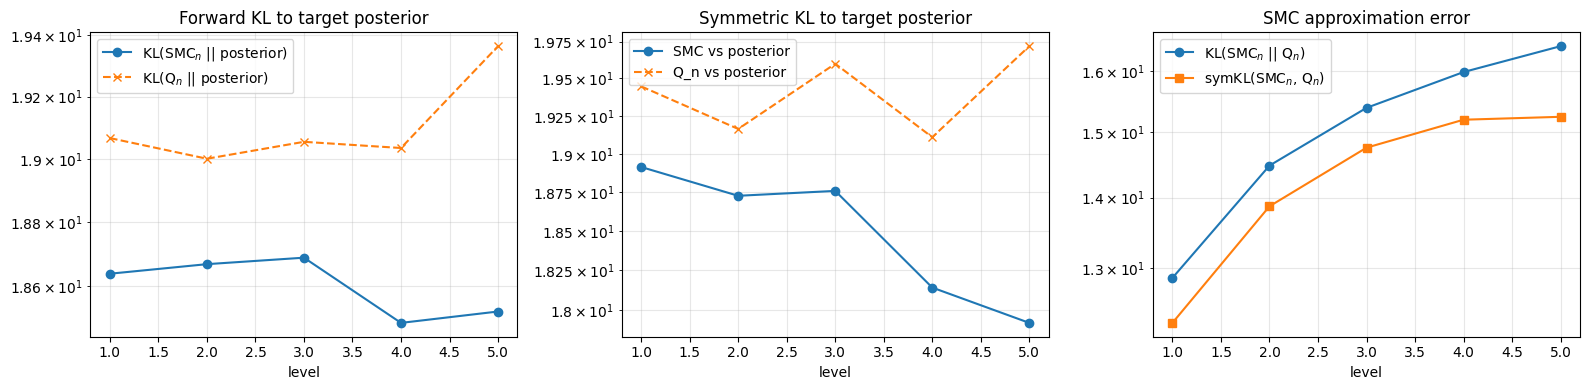

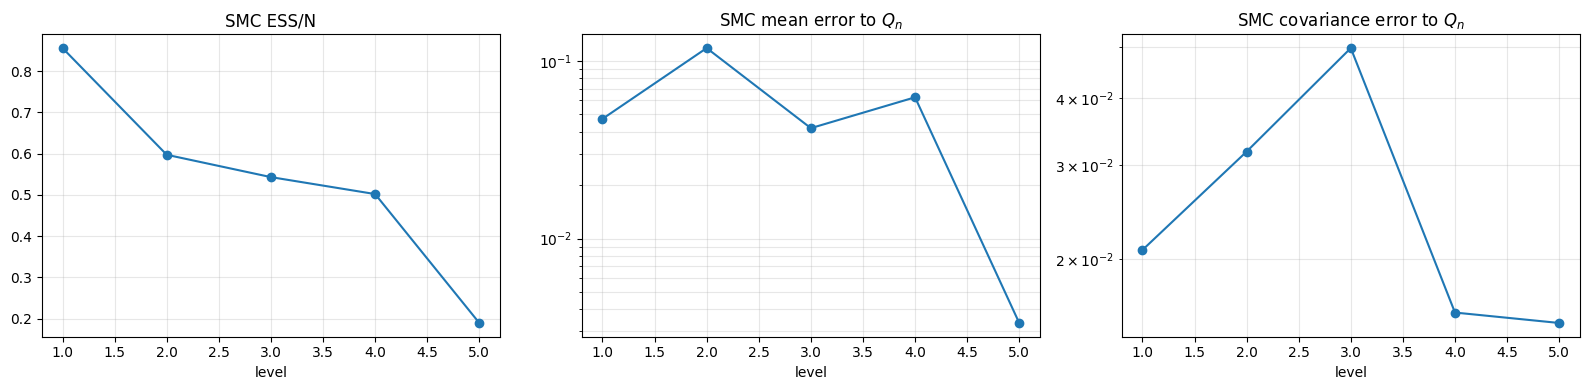

KL(SMC_n || posterior): [18.6377083  18.66761817 18.68792308 18.48457738 18.51990021]
symKL(SMC_n, posterior): [18.91320847 18.72617766 18.75777979 18.14207817 17.92227897]
KL(Q_n || posterior): [19.0667792  19.00080958 19.05480746 19.03504444 19.36309812]
symKL(Q_n, posterior): [19.44709781 19.16336637 19.59946117 19.10869596 19.71886236]
KL(SMC_n || Q_n): [12.86229744 14.4814334  15.39209539 15.9848946  16.42771553]
symKL(SMC_n, Q_n): [12.265822   13.87250862 14.75815737 15.20030678 15.24712201]
SMC mean relative L2 to Q_n: [0.04724779 0.11837748 0.04187433 0.06250836 0.00334231]
SMC covariance relative Frobenius to Q_n: [0.02079914 0.03179911 0.04970708 0.01588017 0.01518186]


In [13]:
# ============================================================
# KL and distribution diagnostics
# ============================================================

def get_plot_range(*sample_sets, pad=0.10, quantile=0.995):
    all_samples = np.concatenate([np.asarray(s) for s in sample_sets], axis=0)
    lo = np.quantile(all_samples, 1.0 - quantile, axis=0)
    hi = np.quantile(all_samples, quantile, axis=0)
    width = hi - lo
    return [[lo[0] - pad*width[0], hi[0] + pad*width[0]], [lo[1] - pad*width[1], hi[1] + pad*width[1]]]


def hist2d_prob(samples, bins=KL_BINS, range_=None, pseudocount=KL_PSEUDOCOUNT):
    H, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, range=range_)
    H = H.astype(np.float64) + pseudocount
    return H / H.sum()


def kl_discrete(P, Q):
    return float(np.sum(P * (np.log(P) - np.log(Q))))


def symmetric_kl(P, Q):
    return 0.5 * (kl_discrete(P, Q) + kl_discrete(Q, P))


def compute_hist_kl(samples, ref_samples, range_):
    P = hist2d_prob(np.asarray(samples), range_=range_)
    Q = hist2d_prob(np.asarray(ref_samples), range_=range_)
    return kl_discrete(P, Q), kl_discrete(Q, P), symmetric_kl(P, Q)


def mean_rel_l2(samples, ref_samples, eps=1e-12):
    m = np.asarray(samples).mean(axis=0)
    r = np.asarray(ref_samples).mean(axis=0)
    return np.linalg.norm(m - r) / (np.linalg.norm(r) + eps)


def cov_rel_fro(samples, ref_samples, eps=1e-12):
    C = np.cov(np.asarray(samples).T)
    R = np.cov(np.asarray(ref_samples).T)
    return np.linalg.norm(C - R, ord="fro") / (np.linalg.norm(R, ord="fro") + eps)


sample_sets = [to_np(s) for s in samples_by_level]
posterior_ref = np.asarray(posterior_samples)
range_ = get_plot_range(posterior_ref, *sample_sets, *target_samples_by_level)
levels = np.arange(1, NUM_SMC_LEVELS + 1)

smc_kl_to_post, smc_symkl_to_post = [], []
qn_kl_to_post, qn_symkl_to_post = [], []
smc_kl_to_qn, smc_symkl_to_qn = [], []
smc_mean_to_qn, smc_cov_to_qn = [], []

for ell in range(NUM_SMC_LEVELS):
    kl, rkl, skl = compute_hist_kl(sample_sets[ell], posterior_ref, range_)
    smc_kl_to_post.append(kl); smc_symkl_to_post.append(skl)
    kl, rkl, skl = compute_hist_kl(target_samples_by_level[ell], posterior_ref, range_)
    qn_kl_to_post.append(kl); qn_symkl_to_post.append(skl)
    kl, rkl, skl = compute_hist_kl(sample_sets[ell], target_samples_by_level[ell], range_)
    smc_kl_to_qn.append(kl); smc_symkl_to_qn.append(skl)
    smc_mean_to_qn.append(mean_rel_l2(sample_sets[ell], target_samples_by_level[ell]))
    smc_cov_to_qn.append(cov_rel_fro(sample_sets[ell], target_samples_by_level[ell]))

smc_kl_to_post = np.asarray(smc_kl_to_post)
smc_symkl_to_post = np.asarray(smc_symkl_to_post)
qn_kl_to_post = np.asarray(qn_kl_to_post)
qn_symkl_to_post = np.asarray(qn_symkl_to_post)
smc_kl_to_qn = np.asarray(smc_kl_to_qn)
smc_symkl_to_qn = np.asarray(smc_symkl_to_qn)
smc_mean_to_qn = np.asarray(smc_mean_to_qn)
smc_cov_to_qn = np.asarray(smc_cov_to_qn)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogy(levels, smc_kl_to_post, marker="o", label=r"KL(SMC$_n$ || posterior)")
axes[0].semilogy(levels, qn_kl_to_post, marker="x", linestyle="--", label=r"KL(Q$_n$ || posterior)")
axes[0].set_title("Forward KL to target posterior")
axes[0].set_xlabel("level")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].semilogy(levels, smc_symkl_to_post, marker="o", label="SMC vs posterior")
axes[1].semilogy(levels, qn_symkl_to_post, marker="x", linestyle="--", label="Q_n vs posterior")
axes[1].set_title("Symmetric KL to target posterior")
axes[1].set_xlabel("level")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

axes[2].semilogy(levels, smc_kl_to_qn, marker="o", label=r"KL(SMC$_n$ || Q$_n$)")
axes[2].semilogy(levels, smc_symkl_to_qn, marker="s", label=r"symKL(SMC$_n$, Q$_n$)")
axes[2].set_title("SMC approximation error")
axes[2].set_xlabel("level")
axes[2].grid(True, which="both", alpha=0.3)
axes[2].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(levels, diagnostics["ess_by_level"] / diagnostics["pop_by_level"], marker="o")
axes[0].set_title("SMC ESS/N")
axes[0].set_xlabel("level")
axes[0].grid(True, alpha=0.3)
axes[1].semilogy(levels, smc_mean_to_qn, marker="o")
axes[1].set_title(r"SMC mean error to $Q_n$")
axes[1].set_xlabel("level")
axes[1].grid(True, which="both", alpha=0.3)
axes[2].semilogy(levels, smc_cov_to_qn, marker="o")
axes[2].set_title(r"SMC covariance error to $Q_n$")
axes[2].set_xlabel("level")
axes[2].grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("KL(SMC_n || posterior):", smc_kl_to_post)
print("symKL(SMC_n, posterior):", smc_symkl_to_post)
print("KL(Q_n || posterior):", qn_kl_to_post)
print("symKL(Q_n, posterior):", qn_symkl_to_post)
print("KL(SMC_n || Q_n):", smc_kl_to_qn)
print("symKL(SMC_n, Q_n):", smc_symkl_to_qn)
print("SMC mean relative L2 to Q_n:", smc_mean_to_qn)
print("SMC covariance relative Frobenius to Q_n:", smc_cov_to_qn)


## 9b. Sliced W2 and residual W2 decay diagnostics


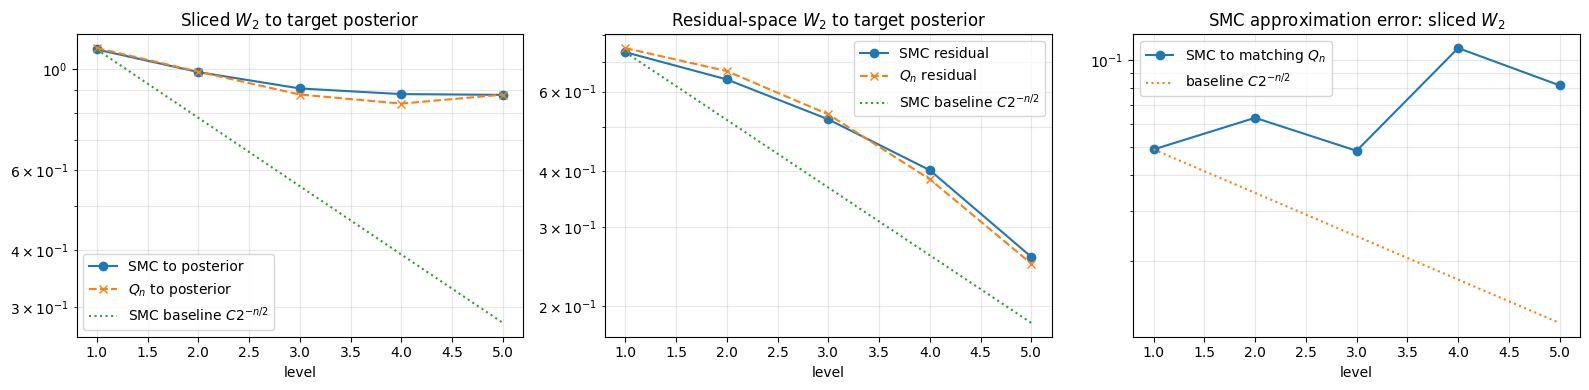

Sliced W2 SMC to posterior: [1.10529623 0.98557574 0.90711939 0.88148406 0.87820719]
Sliced W2 Q_n to posterior: [1.11317617 0.9876708  0.87952563 0.8401417  0.87916889]
Residual W2 SMC to posterior: [0.73462826 0.6389416  0.52080387 0.40144128 0.2575071 ]
Residual W2 Q_n to posterior: [0.75003225 0.6668055  0.53432524 0.38333443 0.24881922]
Sliced W2 SMC to Q_n: [0.0489059  0.06299121 0.04838896 0.10996506 0.08160768]


In [14]:

# ============================================================
# W2 decay diagnostics
# ============================================================

def random_subsample(X, k=None, seed=0):
    X = np.asarray(X)
    if k is None or k >= len(X):
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=k, replace=False)
    return X[idx]


def sliced_wasserstein_2d(X, Y, num_projections=256, max_points=5000, seed=0):
    X = random_subsample(np.asarray(X), max_points, seed=seed)
    Y = random_subsample(np.asarray(Y), max_points, seed=seed + 1)
    k = min(len(X), len(Y))
    X = X[:k]
    Y = Y[:k]
    rng = np.random.default_rng(seed)
    dirs = rng.normal(size=(num_projections, X.shape[1]))
    dirs = dirs / np.linalg.norm(dirs, axis=1, keepdims=True)
    Xp = np.sort(X @ dirs.T, axis=0)
    Yp = np.sort(Y @ dirs.T, axis=0)
    return np.sqrt(np.mean((Xp - Yp) ** 2))


def one_dim_w2(u, v):
    u = np.asarray(u).reshape(-1)
    v = np.asarray(v).reshape(-1)
    k = min(len(u), len(v))
    return np.sqrt(np.mean((np.sort(u[:k]) - np.sort(v[:k])) ** 2))


def residual_w2(X, Y, A, y, max_points=5000, seed=0):
    X = random_subsample(np.asarray(X), max_points, seed=seed)
    Y = random_subsample(np.asarray(Y), max_points, seed=seed + 1)
    RX = X @ A.T - y[None, :]
    RY = Y @ A.T - y[None, :]
    if RX.shape[1] == 1:
        return one_dim_w2(RX[:, 0], RY[:, 0])
    return sliced_wasserstein_2d(RX, RY, num_projections=128, max_points=max_points, seed=seed)


sample_sets_np = [to_np(s) for s in samples_by_level]
posterior_ref = np.asarray(posterior_samples)
A_np = np.asarray(A_OBS)
y_np = np.asarray(y_obs)
levels = np.arange(1, NUM_SMC_LEVELS + 1)

smc_sw2_to_post = np.array([
    sliced_wasserstein_2d(sample_sets_np[ell], posterior_ref, num_projections=256, max_points=5000, seed=100 + ell)
    for ell in range(NUM_SMC_LEVELS)
])

qn_sw2_to_post = np.array([
    sliced_wasserstein_2d(target_samples_by_level[ell], posterior_ref, num_projections=256, max_points=5000, seed=200 + ell)
    for ell in range(NUM_SMC_LEVELS)
])

smc_resid_w2_to_post = np.array([
    residual_w2(sample_sets_np[ell], posterior_ref, A_np, y_np, max_points=5000, seed=300 + ell)
    for ell in range(NUM_SMC_LEVELS)
])

qn_resid_w2_to_post = np.array([
    residual_w2(target_samples_by_level[ell], posterior_ref, A_np, y_np, max_points=5000, seed=400 + ell)
    for ell in range(NUM_SMC_LEVELS)
])

smc_sw2_to_qn = np.array([
    sliced_wasserstein_2d(sample_sets_np[ell], target_samples_by_level[ell], num_projections=256, max_points=5000, seed=500 + ell)
    for ell in range(NUM_SMC_LEVELS)
])


def baseline_half(values, levels):
    c = values[0] * 2.0 ** (levels[0] / 2.0)
    return c * 2.0 ** (-levels / 2.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].semilogy(levels, smc_sw2_to_post, marker="o", label="SMC to posterior")
axes[0].semilogy(levels, qn_sw2_to_post, marker="x", linestyle="--", label=r"$Q_n$ to posterior")
axes[0].semilogy(levels, baseline_half(smc_sw2_to_post, levels), linestyle=":", label=r"SMC baseline $C2^{-n/2}$")
axes[0].set_title(r"Sliced $W_2$ to target posterior")
axes[0].set_xlabel("level")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].semilogy(levels, smc_resid_w2_to_post, marker="o", label="SMC residual")
axes[1].semilogy(levels, qn_resid_w2_to_post, marker="x", linestyle="--", label=r"$Q_n$ residual")
axes[1].semilogy(levels, baseline_half(smc_resid_w2_to_post, levels), linestyle=":", label=r"SMC baseline $C2^{-n/2}$")
axes[1].set_title(r"Residual-space $W_2$ to target posterior")
axes[1].set_xlabel("level")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

axes[2].semilogy(levels, smc_sw2_to_qn, marker="o", label=r"SMC to matching $Q_n$")
axes[2].semilogy(levels, baseline_half(smc_sw2_to_qn, levels), linestyle=":", label=r"baseline $C2^{-n/2}$")
axes[2].set_title(r"SMC approximation error: sliced $W_2$")
axes[2].set_xlabel("level")
axes[2].grid(True, which="both", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Sliced W2 SMC to posterior:", smc_sw2_to_post)
print("Sliced W2 Q_n to posterior:", qn_sw2_to_post)
print("Residual W2 SMC to posterior:", smc_resid_w2_to_post)
print("Residual W2 Q_n to posterior:", qn_resid_w2_to_post)
print("Sliced W2 SMC to Q_n:", smc_sw2_to_qn)


## 9. Scatter comparison: SMC, level target, and final posterior


In [ ]:
# ============================================================
# Scatter comparison by level
# ============================================================

rng = np.random.default_rng(321)
fig, axes = plt.subplots(1, NUM_SMC_LEVELS, figsize=(4.5 * NUM_SMC_LEVELS, 4.2), squeeze=False)
axes = axes[0]

for ell in range(NUM_SMC_LEVELS):
    ax = axes[ell]
    smc = sample_sets[ell]
    qn = target_samples_by_level[ell]
    for arr, label, alpha, s in [
        (posterior_ref, "target posterior", 0.18, 8),
        (qn, f"Q_{ell+1}", 0.25, 8),
        (smc, "SMC", 0.55, 8),
    ]:
        idx = rng.choice(len(arr), size=min(2000, len(arr)), replace=False)
        ax.scatter(arr[idx, 0], arr[idx, 1], s=s, alpha=alpha, label=label)
    xx = np.linspace(range_[0][0], range_[0][1], 200)
    ax.plot(xx, -xx, "k--", linewidth=1.2)
    ax.set_xlim(range_[0])
    ax.set_ylim(range_[1])
    ax.set_title(f"level {ell+1}")
    ax.grid(True, alpha=0.3)
    if ell == 0:
        ax.legend(fontsize=8)

plt.suptitle("SMC vs level target Q_n vs final posterior")
plt.tight_layout()
plt.show()
